<a href="https://colab.research.google.com/github/luisgogu/cs666student/blob/main/CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

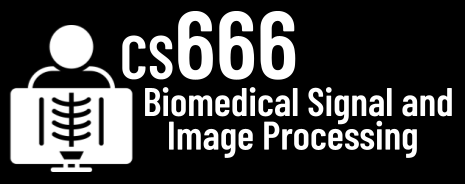
#Assignment 6

In [ ]:
# NAME: Luis Gonzalez

In [ ]:
# In this assignment, we will visualize and explore a CT scan!

In [41]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['axes']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [42]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [ ]:
# Use wget to download https://cs666.org/data/ct.zip
# This is a CT scan of an arm in DICOM format.

In [43]:
!wget https://cs666.org/data/ct.zip

--2026-04-29 17:09:43--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip.1’

ct.zip.1            100%[===================>]   5.58M  --.-KB/s    in 0.1s    

2026-04-29 17:09:43 (53.8 MB/s) - ‘ct.zip.1’ saved [5847706/5847706]



In [ ]:
# Then use the following snippet to extract the data.

In [44]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [45]:
import os
len(os.listdir('ct'))

220

In [ ]:
# TODO: 216 slices.

In [ ]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

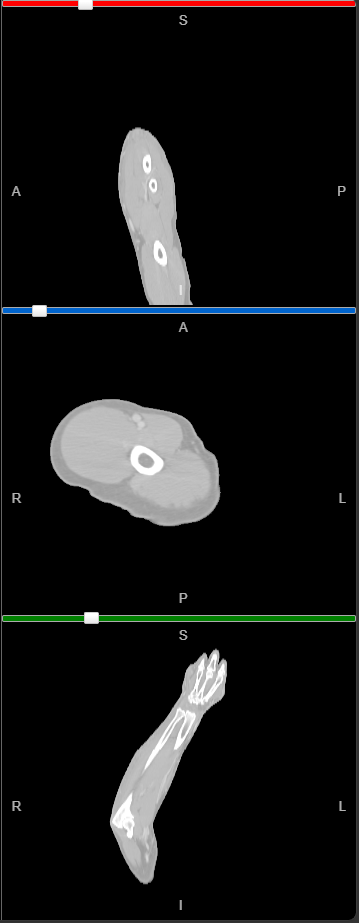

In [ ]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

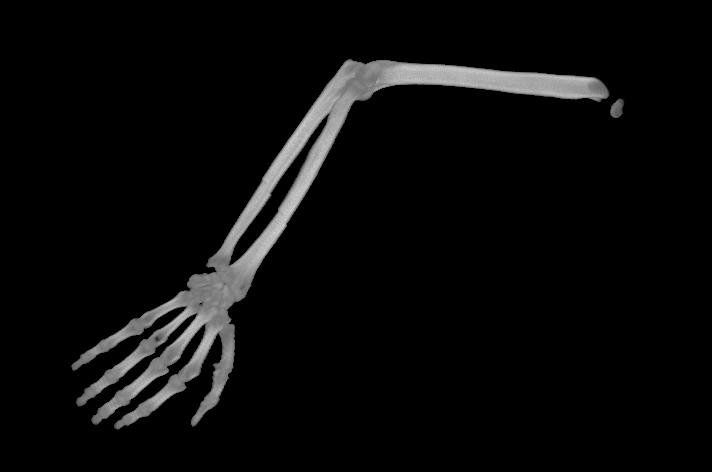

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [ ]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [46]:
from pydicom import dcmread
import numpy as np

In [48]:
filenames = os.listdir('ct')
filenames.sort()

first_file_path = os.path.join('ct', filenames[0])
first_slice = dcmread(first_file_path)
img_shape = first_slice.pixel_array.shape


num_slices = len(filenames)
ct_volume = np.zeros((num_slices, img_shape[0], img_shape[1]), dtype=first_slice.pixel_array.dtype)

# Loop through all the sorted DICOM files
for i, filename in enumerate(filenames):
    file_path = os.path.join('ct', filename)
    dataset = dcmread(file_path)
    ct_volume[i, :, :] = dataset.pixel_array

In [ ]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

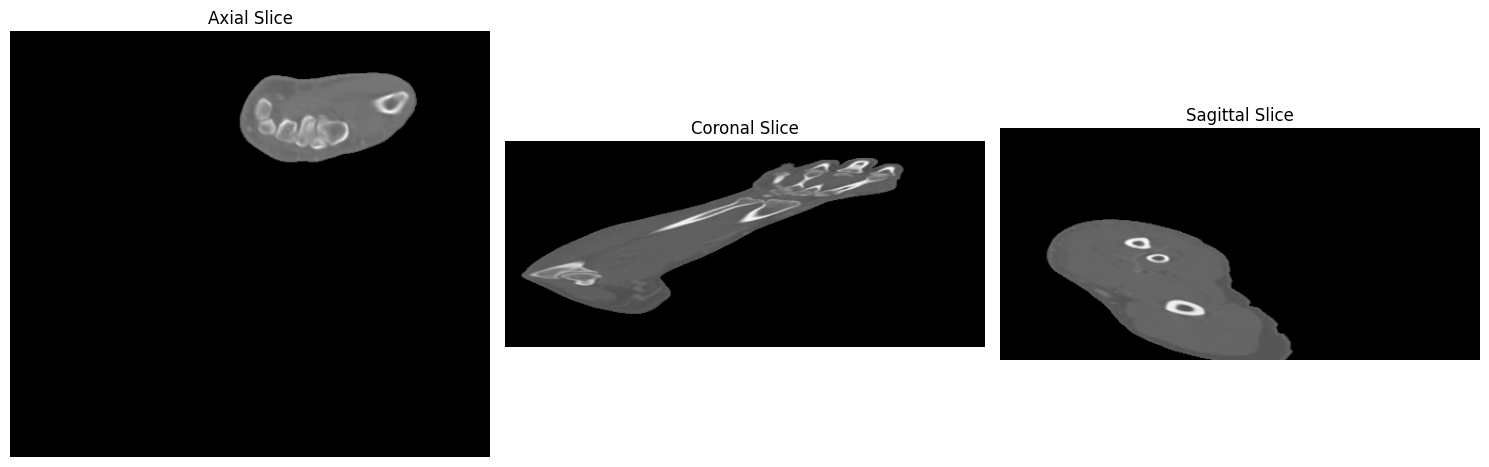

In [49]:
mid_z = ct_volume.shape[0] // 4
mid_y = ct_volume.shape[1] // 4
mid_x = ct_volume.shape[2] // 4

axial_slice = ct_volume[mid_z, :, :]
coronal_slice = ct_volume[:, mid_y, :]
sagittal_slice = ct_volume[:, :, mid_x]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axes[0].imshow(axial_slice, cmap='gray')
axes[0].set_title('Axial Slice')
axes[0].axis('off')

# Coronal
axes[1].imshow(coronal_slice, cmap='gray')
axes[1].set_title('Coronal Slice')
axes[1].axis('off')

# Sagittal
axes[2].imshow(sagittal_slice, cmap='gray')
axes[2].set_title('Sagittal Slice')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [ ]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [ ]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

Window Center (Level): 30.0
Window Width: 410.0
Rescale Intercept: -1024.0


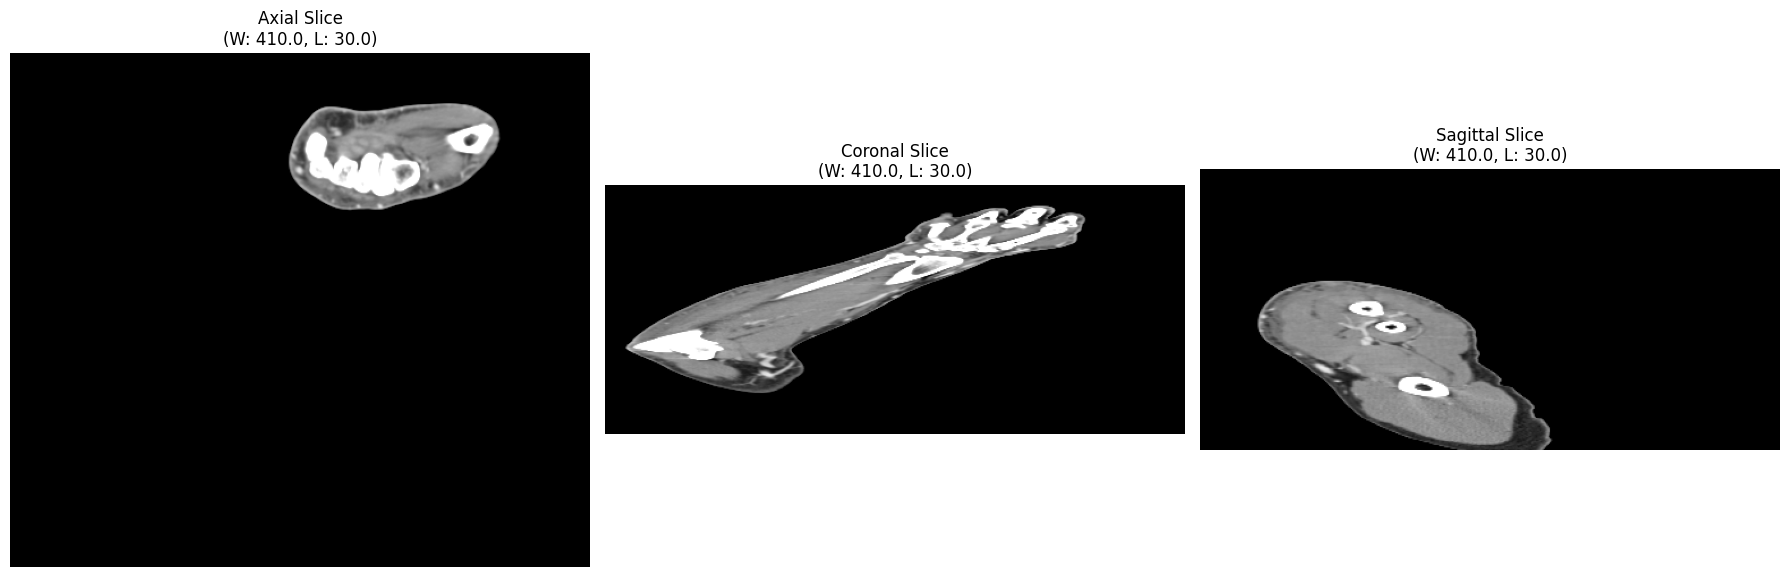

In [50]:
level_raw = first_slice[0x0028, 0x1050].value
window_raw = first_slice[0x0028, 0x1051].value
rescale_raw = first_slice[0x0028, 0x1052].value

level = float(level_raw)
window = float(window_raw)
rescale = float(rescale_raw)

print(f"Window Center (Level): {level}")
print(f"Window Width: {window}")
print(f"Rescale Intercept: {rescale}")

vmin = level - window / 2
vmax = level + window / 2

hu_axial = axial_slice + rescale
hu_coronal = coronal_slice + rescale
hu_sagittal = sagittal_slice + rescale

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(hu_axial, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Axial Slice\n(W: {window}, L: {level})')
axes[0].axis('off')

axes[1].imshow(hu_coronal, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Coronal Slice\n(W: {window}, L: {level})')
axes[1].axis('off')

axes[2].imshow(hu_sagittal, cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Sagittal Slice\n(W: {window}, L: {level})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

In [51]:
import ipywidgets as widgets
from IPython.display import display

def plot_window_level(window, level):
    # Calculate vmin and vmax
    vmin = level - (window / 2)
    vmax = level + (window / 2)

    # Create the plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(hu_axial, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title(f'Axial Slice\n(W: {window}, L: {level})')
    axes[0].axis('off')

    axes[1].imshow(hu_coronal, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Coronal Slice\n(W: {window}, L: {level})')
    axes[1].axis('off')

    axes[2].imshow(hu_sagittal, cmap='gray', vmin=vmin, vmax=vmax)
    axes[2].set_title(f'Sagittal Slice\n(W: {window}, L: {level})')
    axes[2].axis('off')

    plt.tight_layout()
    # plt.show()

# Create the interactive sliders
widgets.interact(
    plot_window_level,
    window=widgets.FloatSlider(value=400, min=10, max=3000, step=10, description='Window Width:'),
    level=widgets.FloatSlider(value=50, min=-1000, max=1000, step=10, description='Level (Center):')
)

interactive(children=(FloatSlider(value=400.0, description='Window Width:', max=3000.0, min=10.0, step=10.0), …

<function __main__.plot_window_level(window, level)>

In [ ]:
# Which values make sense and why?

In [ ]:
# The values that make the most sense are a Level of 400 and a Window of 1110.
# Because this is a scan of an arm, the primary structures of interest are the bones.
# Setting the Level to 400 targets the high density of bone tissue, which causes the
# less dense tissues like muscle and fat to fall below the visible range and turn pitch black.
# Using a wide Window of 1110 stretches the grayscale just enough to reveal the internal texture of the bone,
# allowing us to distinguish the bright outer shell from the slightly darker inside.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [ ]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

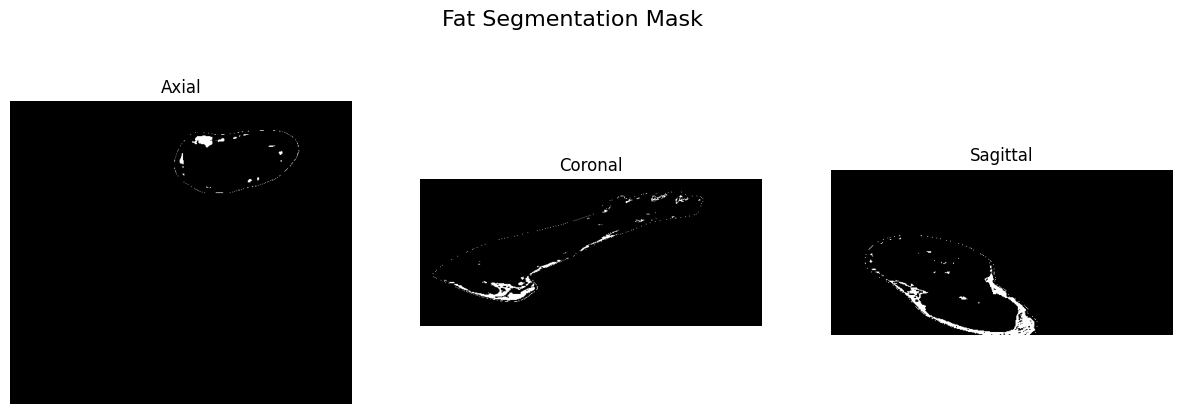

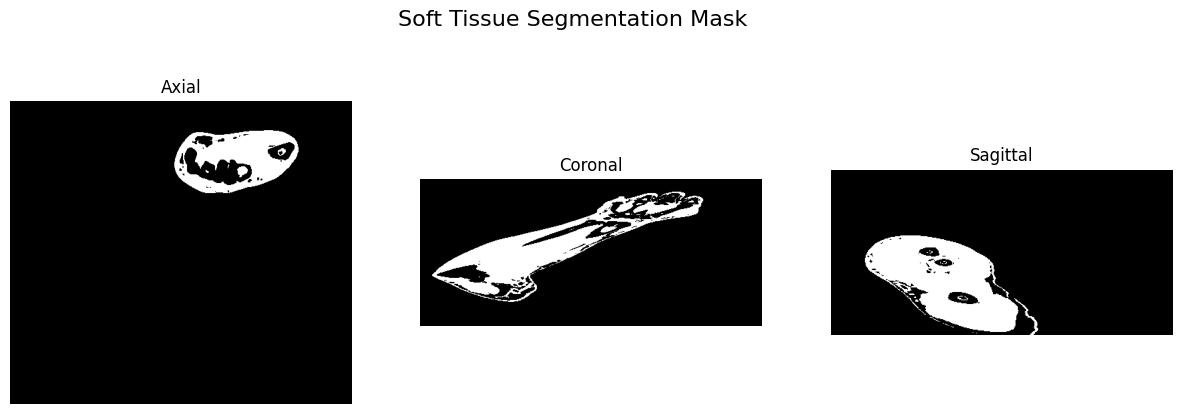

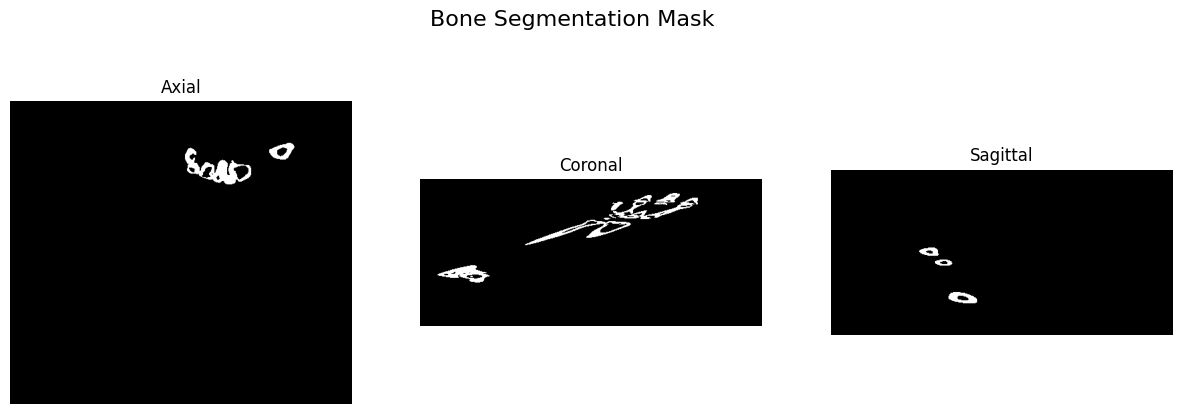

In [52]:
hu_volume = ct_volume.astype(np.int16) + rescale

fat_mask = np.logical_and(hu_volume >= -120, hu_volume <= -50).astype(np.int16)
soft_tissue_mask = np.logical_and(hu_volume > -50, hu_volume <= 150).astype(np.int16)

bone_mask = (hu_volume > 300).astype(np.int16)

# 2) Visualization Function
def plot_segmentation(mask, title):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)

    axes[0].imshow(mask[mid_z, :, :], cmap='gray')
    axes[0].set_title('Axial')
    axes[0].axis('off')

    axes[1].imshow(mask[:, mid_y, :], cmap='gray')
    axes[1].set_title('Coronal')
    axes[1].axis('off')

    axes[2].imshow(mask[:, :, mid_x], cmap='gray')
    axes[2].set_title('Sagittal')
    axes[2].axis('off')

    plt.show()

# Visualize each structure
plot_segmentation(fat_mask, "Fat Segmentation Mask")
plot_segmentation(soft_tissue_mask, "Soft Tissue Segmentation Mask")
plot_segmentation(bone_mask, "Bone Segmentation Mask")

In [ ]:
# Are the segmentations good?

In [ ]:
#The segmentations are effective because they isolate distinct structures by leveraging their specific HU signatures.
#The bone mask correctly identifies the dense shell while maintaining a hollow center for the less dense cavity,
# and the soft tissue and fat masks successfully partition muscles and adipose layers using their characteristic density ranges.

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""